<a href="https://colab.research.google.com/github/LielUziahu/L.Uziahu_Lab_Notebook-Mass_Lab/blob/master/Planulae_Volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

loading 2026 file, Doing ratio >2.5 QC (removine bias planulae that wheren horizantle while imaging) and check for normality

--- 2026 DATA REMOVAL REPORT ---
Total larvae ignored: 4
      no morph  Label  Aspect_Ratio
50    51    HF      1      1.783012
81    82    HF     11      2.254283
94    95    NF      2      2.248411
101  102    NF      4      1.653646
----------------------------------------

--- 2026 NORMALITY TEST (Excluding larvae with Ratio < 2.5) ---
Morph: HF (n=90) | Shapiro-Wilk p-value: 0.01723 | NOT Normal ❌
Morph: NF (n=44) | Shapiro-Wilk p-value: 0.57169 | Normal ✅


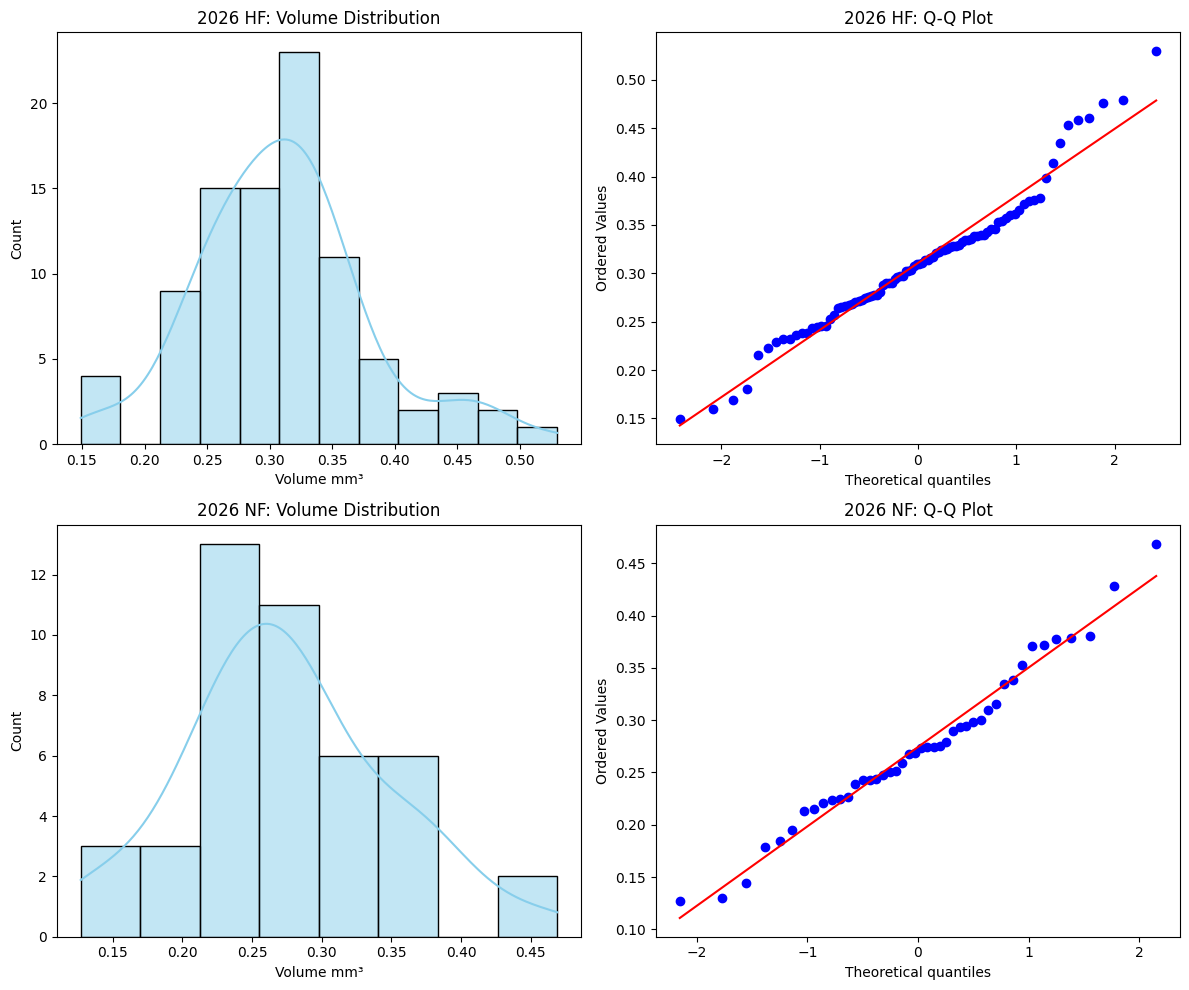


Final Morph Comparison (2026 Cleaned Data): p = 0.00464


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load 2026 Data
# Fixed: Updated filename and added encoding to handle µ symbol
file_2026 = 'Planulae size 2026.csv'
df26 = pd.read_csv(file_2026, encoding='latin-1')
df26.columns = df26.columns.str.strip()

# 2. Geometric Filtering (Aspect Ratio >= 2.5)
A = df26['area µm²']
P = df26['perimeter µm']
r = (P - np.sqrt(P**2 - 4 * np.pi * A)) / (2 * np.pi)
w = 2 * r
L_total = ((P - 2 * np.pi * r) / 2) + (2 * r)
df26['Aspect_Ratio'] = L_total / w

# Identify removed data
df26_removed = df26[df26['Aspect_Ratio'] < 2.5]
df26_good = df26[df26['Aspect_Ratio'] >= 2.5].copy()

# 3. Print Data Removal Report
print(f"--- 2026 DATA REMOVAL REPORT ---")
print(f"Total larvae ignored: {len(df26_removed)}")
if not df26_removed.empty:
    print(df26_removed[['no', 'morph', 'Label', 'Aspect_Ratio']])
print("-" * 40)

# 4. Normality Test & Plotting
unique_morphs = df26_good['morph'].unique()
fig, axes = plt.subplots(len(unique_morphs), 2, figsize=(12, 5 * len(unique_morphs)))

print("\n--- 2026 NORMALITY TEST (Excluding larvae with Ratio < 2.5) ---")
for i, morph in enumerate(unique_morphs):
    data = df26_good[df26_good['morph'] == morph]['Volume mm³'].dropna()
    shapiro_p = stats.shapiro(data)[1]
    result = "Normal ✅" if shapiro_p > 0.05 else "NOT Normal ❌"
    print(f"Morph: {morph} (n={len(data)}) | Shapiro-Wilk p-value: {shapiro_p:.5f} | {result}")

    # Histogram
    sns.histplot(data, kde=True, ax=axes[i][0], color='skyblue')
    axes[i][0].set_title(f'2026 {morph}: Volume Distribution')

    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[i][1])
    axes[i][1].set_title(f'2026 {morph}: Q-Q Plot')

plt.tight_layout()
plt.show()

# 5. Final Comparison
stat, p_comp = stats.mannwhitneyu(df26_good[df26_good['morph'] == 'HF']['Volume mm³'],
                                 df26_good[df26_good['morph'] == 'NF']['Volume mm³'])
print(f"\nFinal Morph Comparison (2026 Cleaned Data): p = {p_comp:.5f}")

loading 2025 file, Doing ratio >2.5 QC (removine bias planulae that wheren horizantle while imaging) and check for normality

--- 2025 DATA REMOVAL REPORT ---
Total larvae ignored: 7
        no morph  Aspect_Ratio
17    18.0    HF      1.913530
27    28.0    HF      2.325424
65    66.0    HF      2.372995
140  141.0    NF      1.763334
144  145.0    NF      1.725900
148  149.0    NF      1.554424
152  153.0    NF      1.701978
----------------------------------------

--- 2025 NORMALITY TEST (Cleaned Data) ---
Morph: HF (n=91) | Shapiro-Wilk p-value: 0.06435 | Normal ✅
Morph: NF (n=56) | Shapiro-Wilk p-value: 0.00006 | NOT Normal ❌


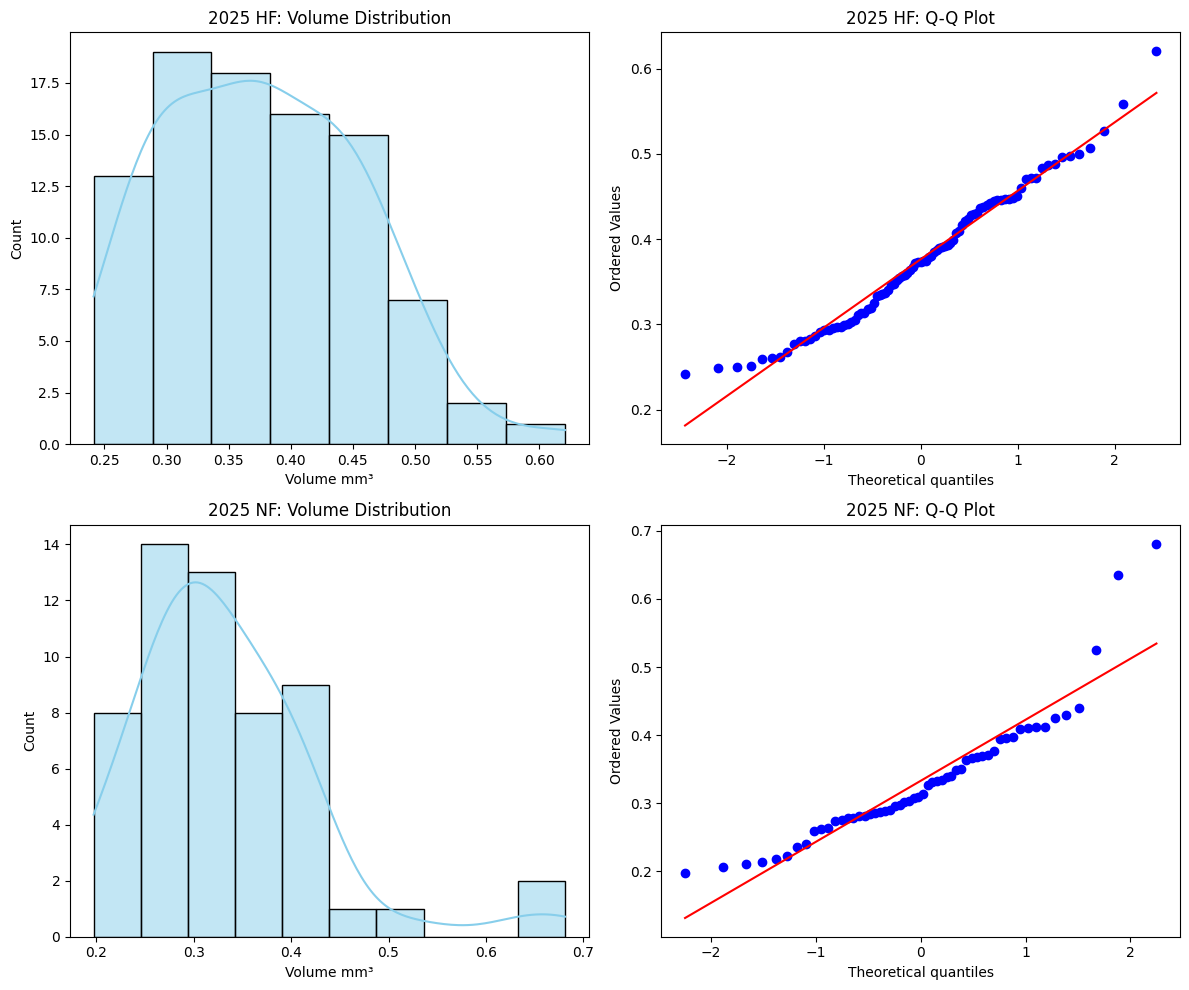


Final Morph Comparison (2025 Cleaned Data): p = 0.00052


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load 2025 Data
file_2025 = 'Planulae size 2025.csv'
# Using latin-1 encoding to handle special characters like µ
df25 = pd.read_csv(file_2025, encoding='latin-1')
df25.columns = df25.columns.str.strip()

# 2. Geometric Filtering (Aspect Ratio >= 2.5)
A = df25['area µm²']
P = df25['perimeter µm']
r = (P - np.sqrt(P**2 - 4 * np.pi * A)) / (2 * np.pi)
w = 2 * r
L_total = ((P - 2 * np.pi * r) / 2) + (2 * r)
df25['Aspect_Ratio'] = L_total / w

# Identify removed data
df25_removed = df25[df25['Aspect_Ratio'] < 2.5]
df25_good = df25[df25['Aspect_Ratio'] >= 2.5].copy()

# 3. Print Data Removal Report
print(f"--- 2025 DATA REMOVAL REPORT ---")
print(f"Total larvae ignored: {len(df25_removed)}")
if not df25_removed.empty:
    print(df25_removed[['no', 'morph', 'Aspect_Ratio']])
print("-" * 40)

# 4. Normality Test & Plotting
unique_morphs = df25_good['morph'].unique()
fig, axes = plt.subplots(len(unique_morphs), 2, figsize=(12, 5 * len(unique_morphs)))

print("\n--- 2025 NORMALITY TEST (Cleaned Data) ---")
for i, morph in enumerate(unique_morphs):
    data = df25_good[df25_good['morph'] == morph]['Volume mm³'].dropna()
    shapiro_p = stats.shapiro(data)[1]
    result = "Normal ✅" if shapiro_p > 0.05 else "NOT Normal ❌"
    print(f"Morph: {morph} (n={len(data)}) | Shapiro-Wilk p-value: {shapiro_p:.5f} | {result}")

    # Histogram
    sns.histplot(data, kde=True, ax=axes[i][0], color='skyblue')
    axes[i][0].set_title(f'2025 {morph}: Volume Distribution')

    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[i][1])
    axes[i][1].set_title(f'2025 {morph}: Q-Q Plot')

plt.tight_layout()
plt.show()

# 5. Final Comparison
stat, p_comp = stats.mannwhitneyu(df25_good[df25_good['morph'] == 'HF']['Volume mm³'],
                                 df25_good[df25_good['morph'] == 'NF']['Volume mm³'])
print(f"\nFinal Morph Comparison (2025 Cleaned Data): p = {p_comp:.5f}")

get avarage size for each morph by year for oxygen consumption rates

In [34]:
# 1. Prepare and Combine the DataFrames
# Add a 'Year' column to distinguish the datasets
df25_good['Year'] = 2025
df26_good['Year'] = 2026

# Combine (concatenate) the cleaned datasets
df_all = pd.concat([df25_good, df26_good], ignore_index=True)

# 2. Calculate the mean volume for each group
respiration_normalization_values = df_all.groupby(['Year', 'morph'])['Volume mm³'].mean().reset_index()

print("--- AVERAGE VOLUME FOR RESPIRATION CALCULATION (mm³) ---")
print("Use these values to normalize your oxygen consumption rates:")
print("-" * 55)
print(respiration_normalization_values)

--- AVERAGE VOLUME FOR RESPIRATION CALCULATION (mm³) ---
Use these values to normalize your oxygen consumption rates:
-------------------------------------------------------
   Year morph  Volume mm³
0  2025    HF    0.376455
1  2025    NF    0.333071
2  2026    HF    0.310692
3  2026    NF    0.274350


# Mann-Whitney U Test (Wilcoxon Rank-Sum Test)
Since normality checks showed that at least one group in each year failed the Shapiro-Wilk test (specifically 2026 HF and 2025 NF),

In [36]:
from scipy.stats import mannwhitneyu

# Run the test
stat26, p26 = mannwhitneyu(df26_good[df26_good['morph'] == 'HF']['Volume mm³'],
                           df26_good[df26_good['morph'] == 'NF']['Volume mm³'],
                           alternative='two-sided')

print(f"2026 Mann-Whitney U p-value: {p26:.5f}")
# If p < 0.05, they are significantly different.
# Check medians to see which is larger.
# Run the test

stat25, p25 = mannwhitneyu(df25_good[df25_good['morph'] == 'HF']['Volume mm³'],
                           df25_good[df25_good['morph'] == 'NF']['Volume mm³'],
                           alternative='two-sided')

print(f"2025 Mann-Whitney U p-value: {p25:.5f}")


2026 Mann-Whitney U p-value: 0.00464
2025 Mann-Whitney U p-value: 0.00052
2578.0


Two-Way ANOVA for morph x year x volume

In [40]:
# 1. Combine the datasets for the ANOVA
df25_good['Year'] = '2025'
df26_good['Year'] = '2026'
df_all = pd.concat([df25_good, df26_good], ignore_index=True)

# 2. Descriptive Stats (N, Mean, SD, Median)
stats_table = df_all.groupby(['Year', 'morph'])['Volume mm³'].agg(['count', 'mean', 'std', 'median']).reset_index()
stats_table.columns = ['Year', 'Morph', 'N', 'Mean', 'SD', 'Median']

# 3. Year-by-Year Comparison (Mann-Whitney U)
mw_results = []
for yr in ['2025', '2026']:
    h = df_all[(df_all['Year'] == yr) & (df_all['morph'] == 'HF')]['Volume mm³']
    n = df_all[(df_all['Year'] == yr) & (df_all['morph'] == 'NF')]['Volume mm³']
    _, p = stats.mannwhitneyu(h, n)
    mw_results.append({'Year': yr, 'Morph Comparison p-value': round(p, 5)})

# 4. Overall Two-Way ANOVA
model = ols('Q("Volume mm³") ~ C(morph) * C(Year)', data=df_all).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

# --- Print the Tables ---
print("TABLE 1: DESCRIPTIVE STATISTICS")
print(stats_table.to_string(index=False))
print("\nTABLE 2: MANN-WHITNEY U (HF vs NF)")
print(pd.DataFrame(mw_results).to_string(index=False))
print("\nTABLE 3: TWO-WAY ANOVA")
print(anova_results)

TABLE 1: DESCRIPTIVE STATISTICS
Year Morph  N     Mean       SD  Median
2025    HF 91 0.376455 0.080022 0.37350
2025    NF 56 0.333071 0.093485 0.31140
2026    HF 90 0.310692 0.069479 0.30965
2026    NF 44 0.274350 0.074602 0.27125

TABLE 2: MANN-WHITNEY U (HF vs NF)
Year  Morph Comparison p-value
2025                   0.00052
2026                   0.00464

TABLE 3: TWO-WAY ANOVA
                    sum_sq     df          F        PR(>F)
C(morph)          0.103488    1.0  16.608952  6.004860e-05
C(Year)           0.279861    1.0  44.915560  1.148268e-10
C(morph):C(Year)  0.000791    1.0   0.126940  7.218972e-01
Residual          1.725940  277.0        NaN           NaN


# remove 1.5 IQR outliers per group

In [39]:
# Function to identify and remove 1.5 IQR outliers per group
def remove_iqr_outliers(df, column):
    cleaned_groups = []
    for (yr, morph), group in df.groupby(['Year', 'morph']):
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        cleaned_groups.append(group[(group[column] >= lower) & (group[column] <= upper)])
    return pd.concat(cleaned_groups)

# Assuming df_all is your combined dataset filtered for Aspect Ratio >= 2.5
df_final = remove_iqr_outliers(df_all, 'Volume mm³')

# Run the final ANOVA
model_final = ols('Q("Volume mm³") ~ C(morph) * C(Year)', data=df_final).fit()
print(sm.stats.anova_lm(model_final, typ=2))

# Count how many were removed
print(f"\nRemoved {len(df_all) - len(df_final)} IQR outliers from the pool.")

                    sum_sq     df          F        PR(>F)
C(morph)          0.136668    1.0  30.151731  9.355408e-08
C(Year)           0.278949    1.0  61.541743  1.068434e-13
C(morph):C(Year)  0.010939    1.0   2.413372  1.214964e-01
Residual          1.201158  265.0        NaN           NaN

Removed 12 IQR outliers from the pool.


Re-Do ANOVA for clean Dataset

In [41]:
from scipy.stats import levene

# 1. Check Homogeneity of Variance (Final ANOVA Assumption)
# We test if the 'spread' of volume is consistent across all groups
stat_lev, p_lev = levene(
    df_final[(df_final['Year']=='2025') & (df_final['morph']=='HF')]['Volume mm³'],
    df_final[(df_final['Year']=='2025') & (df_final['morph']=='NF')]['Volume mm³'],
    df_final[(df_final['Year']=='2026') & (df_final['morph']=='HF')]['Volume mm³'],
    df_final[(df_final['Year']=='2026') & (df_final['morph']=='NF')]['Volume mm³']
)

print(f"Levene's Test p-value: {p_lev:.4f}")
if p_lev > 0.05:
    print("Assumption Met: Variances are equal ✅")
else:
    print("Assumption Violated: Variances are unequal (Consider weighted ANOVA) ⚠️")

# 2. Re-run Final Conclusive ANOVA
model_final = ols('Q("Volume mm³") ~ C(morph) * C(Year)', data=df_final).fit()
print("\n--- FINAL CONCLUSIVE ANOVA TABLE ---")
print(sm.stats.anova_lm(model_final, typ=2))

Levene's Test p-value: 0.0006
Assumption Violated: Variances are unequal (Consider weighted ANOVA) ⚠️

--- FINAL CONCLUSIVE ANOVA TABLE ---
                    sum_sq     df          F        PR(>F)
C(morph)          0.136668    1.0  30.151731  9.355408e-08
C(Year)           0.278949    1.0  61.541743  1.068434e-13
C(morph):C(Year)  0.010939    1.0   2.413372  1.214964e-01
Residual          1.201158  265.0        NaN           NaN


WEIGHTED ANOVA RESULTS

In [44]:
import statsmodels.api as sm
from statsmodels.formula.api import wls

# 1. Calculate weights (1 / variance of each group)
# This accounts for the unequal spread of the data
group_variances = df_final.groupby(['Year', 'morph'])['Volume mm³'].transform('var')
weights = 1.0 / group_variances

# 2. Run the WEIGHTED ANOVA (The 'Audit-Proof' version)
weighted_model = wls('Q("Volume mm³") ~ C(morph) * C(Year)', data=df_final, weights=weights).fit()
weighted_anova = sm.stats.anova_lm(weighted_model, typ=2)

print("--- WEIGHTED ANOVA RESULTS (Corrected for Unequal Variance) ---")
print(weighted_anova)

--- WEIGHTED ANOVA RESULTS (Corrected for Unequal Variance) ---
                      sum_sq     df          F        PR(>F)
C(morph)           28.535593    1.0  28.535593  1.981931e-07
C(Year)            63.420027    1.0  63.420027  4.938668e-14
C(morph):C(Year)    2.450623    1.0   2.450623  1.186716e-01
Residual          265.000000  265.0        NaN           NaN


## FINAL SUMMARY STATISTICS

In [45]:
# 1. Generate the Descriptive Statistics Table for the final cleaned data
# This assumes 'df_final' is your double-cleaned dataset
final_summary_stats = df_final.groupby(['Year', 'morph'])['Volume mm³'].agg(
    N='count',
    Mean='mean',
    SD='std',
    Median='median'
).reset_index()

# 2. Round the values for a clean publication look
final_summary_stats = final_summary_stats.round({'Mean': 4, 'SD': 4, 'Median': 4})

print("--- FINAL SUMMARY STATISTICS: DOUBLE-CLEANED DATA ---")
print("(Filtered for Aspect Ratio >= 2.5 AND 1.5 IQR Outliers Removed)")
print("-" * 55)
print(final_summary_stats.to_string(index=False))

--- FINAL SUMMARY STATISTICS: DOUBLE-CLEANED DATA ---
(Filtered for Aspect Ratio >= 2.5 AND 1.5 IQR Outliers Removed)
-------------------------------------------------------
Year morph  N   Mean     SD  Median
2025    HF 91 0.3765 0.0800  0.3735
2025    NF 53 0.3172 0.0647  0.3081
2026    HF 82 0.3024 0.0505  0.3058
2026    NF 43 0.2698 0.0691  0.2690


Plotting

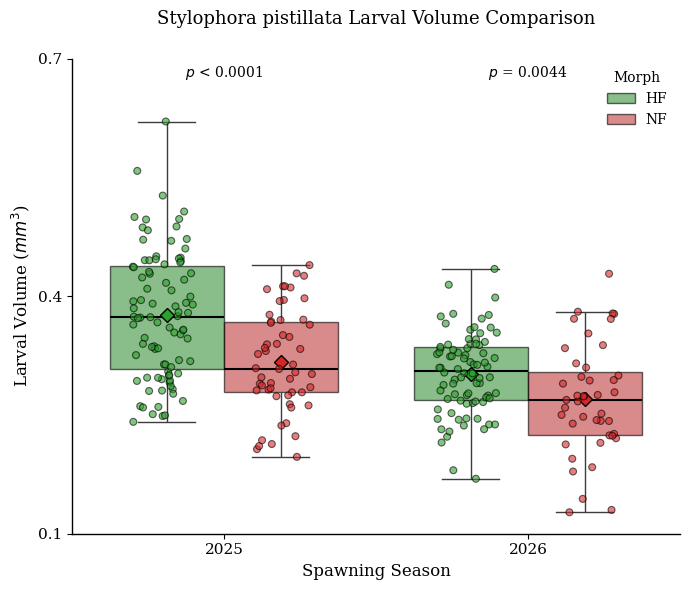

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. GLOBAL SETUP & STYLE
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
morph_order = ['HF', 'NF']

def get_cleaned_data(filename, year_label):
    df = pd.read_csv(filename, encoding='latin-1')
    df.columns = df.columns.str.strip()

    # Orientation Filter
    A, P = df['area µm²'], df['perimeter µm']
    r = (P - np.sqrt(P**2 - 4 * np.pi * A)) / (2 * np.pi)
    L_total = ((P - 2 * np.pi * r) / 2) + (2 * r)
    df['Aspect_Ratio'] = L_total / (2 * r)
    df = df[df['Aspect_Ratio'] >= 2.5].copy()
    df['Year'] = year_label

    # IQR Outlier Removal
    cleaned_groups = []
    for morph in df['morph'].unique():
        group = df[df['morph'] == morph].copy()
        Q1, Q3 = group['Volume mm³'].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        group_cleaned = group[(group['Volume mm³'] >= Q1 - 1.5 * IQR) &
                              (group['Volume mm³'] <= Q3 + 1.5 * IQR)]
        cleaned_groups.append(group_cleaned)
    return pd.concat(cleaned_groups)

# Load and clean
df25 = get_cleaned_data('Planulae size 2025.csv', '2025')
df26 = get_cleaned_data('Planulae size 2026.csv', '2026')
df_final = pd.concat([df25, df26], ignore_index=True)

# Calculate p-values for annotation
def get_p_val(df_yr):
    h = df_yr[df_yr['morph'] == 'HF']['Volume mm³']
    n = df_yr[df_yr['morph'] == 'NF']['Volume mm³']
    _, p = stats.mannwhitneyu(h, n)
    return p

p25 = get_p_val(df25)
p26 = get_p_val(df26)

# Format p-value string
def format_p(p):
    return "$p$ < 0.0001" if p < 0.0001 else f"$p$ = {p:.4f}"

# ==========================================
# 2. PLOTTING
# ==========================================
plt.figure(figsize=(7, 6))

# Boxplot with Mean Diamonds
ax = sns.boxplot(
    data=df_final, x='Year', y='Volume mm³', hue='morph',
    palette=variant_colors, hue_order=morph_order,
    width=0.75, showfliers=False,
    showmeans=True,
    meanprops={"marker":"D", "markeredgecolor":"black", "markersize":"7"},
    boxprops=dict(alpha=0.6, edgecolor='black', linewidth=1),
    medianprops=dict(color='black', linewidth=1.5)
)

# Manually setting colors for each mean diamond marker individually
means = [line for line in ax.get_lines() if line.get_marker() == 'D']

# 2025 HF (Index 0)
means[0].set_markerfacecolor('#2ca02c')
# 2025 NF (Index 1)
means[1].set_markerfacecolor('#2ca02c')
# 2026 HF (Index 2)
means[2].set_markerfacecolor('#d62728')
# 2026 NF (Index 3)
means[3].set_markerfacecolor('#d62728')

# Individual data points (Stripplot)
sns.stripplot(
    data=df_final, x='Year', y='Volume mm³', hue='morph',
    palette=variant_colors, hue_order=morph_order,
    dodge=True, alpha=0.6, jitter=0.2, size=5, ax=ax,
    linewidth=0.8, edgecolor='black'
)

# Add P-value Annotations with < 0.0001 logic
y_pos = df_final['Volume mm³'].max() + 0.05
plt.text(0, y_pos, format_p(p25), ha='center', va='bottom', fontsize=10, fontweight='light')
plt.text(1, y_pos, format_p(p26), ha='center', va='bottom', fontsize=10, fontweight='light')

# Set y-axis ticks
y_max = df_final['Volume mm³'].max()
plt.yticks(np.arange(0.1, y_max + 0.2, 0.3))

# Legend adjustment
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Morph", loc='upper right')

plt.ylabel("Larval Volume ($mm^3$)", fontsize=12, fontweight='light')
plt.xlabel("Spawning Season", fontsize=12, fontweight='light')
plt.title("Stylophora pistillata Larval Volume Comparison", fontsize=13, pad=25)

sns.despine()
plt.tight_layout()
plt.savefig('Larval_Volume.pdf', dpi=600)
plt.show()